## Random Forest

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn

  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using ca

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("C:\\Users\\guntu\\OneDrive\\Desktop\\Random Forerst\\Random Forest\\random_forest_customer_churn_messy_2000.csv")
df

,customer_age,annual_income,tenure_months,monthly_bill,support_calls,complaints,data_usage_gb,late_payments,satisfaction_score,discount_percent,contract_type,internet_service,payment_method,region,churn
0,55.0,62038.0,24.7,88.11,1.0,1.0,20.15,1.0,6.1,20.1,NaN,Fiber,AutoPay,North,1
1,35.0,79163.0,84.5,450.00,3.0,2.0,25.61,2.0,6.4,16.9,Two year,DSL,Credit Card,East,0
2,46.0,72884.0,17.4,72.68,2.0,0.0,3.37,2.0,8.4,10.9,Month-to-month,fiber,Bank Transfer,West,0
3,NaN,44419.0,24.5,NaN,2.0,1.0,13.42,2.0,6.0,3.2,Month-to-month,Fiber,AutoPay,South,1
4,31.0,93307.0,43.7,71.38,3.0,0.0,13.88,0.0,8.1,6.7,One year,Fiber,UPI,North,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,40.0,NaN,46.1,101.34,1.0,1.0,NaN,2.0,5.4,21.2,Two year,DSL,Credit Card,South,1
1996,43.0,20620.0,11.7,118.82,1.0,NaN,22.04,NaN,7.1,0.0,Month-to-month,Fiber,Cash,North,1
1997,NaN,128762.0,22.3,60.75,3.0,0.0,20.87,0.0,7.5,21.2,One year,Fiber,NaN,Central,0
1998,48.0,123038.0,25.8,42.61,3.0,1.0,28.78,NaN,7.9,22.7,Month-to-month,Fiber,Credit Card,South,1


In [4]:
df.head()

,customer_age,annual_income,tenure_months,monthly_bill,support_calls,complaints,data_usage_gb,late_payments,satisfaction_score,discount_percent,contract_type,internet_service,payment_method,region,churn
0,55.0,62038.0,24.7,88.11,1.0,1.0,20.15,1.0,6.1,20.1,NaN,Fiber,AutoPay,North,1
1,35.0,79163.0,84.5,450.00,3.0,2.0,25.61,2.0,6.4,16.9,Two year,DSL,Credit Card,East,0
2,46.0,72884.0,17.4,72.68,2.0,0.0,3.37,2.0,8.4,10.9,Month-to-month,fiber,Bank Transfer,West,0
3,NaN,44419.0,24.5,NaN,2.0,1.0,13.42,2.0,6.0,3.2,Month-to-month,Fiber,AutoPay,South,1
4,31.0,93307.0,43.7,71.38,3.0,0.0,13.88,0.0,8.1,6.7,One year,Fiber,UPI,North,0


In [5]:
# check null values - datpreproccessing
df.isnull().sum()

customer_age           99
annual_income          79
tenure_months          60
monthly_bill           54
support_calls          72
complaints             74
data_usage_gb         109
late_payments         106
satisfaction_score     82
discount_percent       64
contract_type          84
internet_service      252
payment_method         69
region                 77
churn                   0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(20)

In [7]:
df.shape

(2000, 15)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_age        1901 non-null   float64
 1   annual_income       1921 non-null   float64
 2   tenure_months       1940 non-null   float64
 3   monthly_bill        1946 non-null   float64
 4   support_calls       1928 non-null   float64
 5   complaints          1926 non-null   float64
 6   data_usage_gb       1891 non-null   float64
 7   late_payments       1894 non-null   float64
 8   satisfaction_score  1918 non-null   float64
 9   discount_percent    1936 non-null   float64
 10  contract_type       1916 non-null   str    
 11  internet_service    1748 non-null   str    
 12  payment_method      1931 non-null   str    
 13  region              1923 non-null   str    
 14  churn               2000 non-null   int64  
dtypes: float64(10), int64(1), str(4)
memory usage: 234.5 KB


In [9]:
df.describe()

,customer_age,annual_income,tenure_months,monthly_bill,support_calls,complaints,data_usage_gb,late_payments,satisfaction_score,discount_percent,churn
count,1901.000000,1.921000e+03,1940.000000,1946.000000,1928.000000,1926.000000,1891.000000,1894.000000,1918.000000,1936.000000,2000.000000
mean,37.420305,7.102378e+04,28.360052,83.080838,2.416494,1.041537,19.153035,1.238120,6.483264,12.283936,0.260000
std,12.139088,9.714917e+04,16.646509,68.482171,2.897000,1.035644,18.713166,1.137092,1.780444,7.564043,0.438744
min,-5.000000,1.800000e+04,1.000000,-20.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,3.860100e+04,16.100000,60.940000,1.000000,0.000000,12.630000,0.000000,5.300000,6.600000,0.000000
50%,37.000000,5.371000e+04,25.500000,77.620000,2.000000,1.000000,17.720000,1.000000,6.500000,12.200000,0.000000
75%,45.000000,8.103200e+04,36.625000,94.827500,3.000000,2.000000,23.190000,2.000000,7.700000,17.625000,1.000000
max,200.000000,1.500000e+06,120.000000,1500.000000,50.000000,6.000000,300.000000,6.000000,10.000000,38.400000,1.000000


In [10]:
df.columns

Index(['customer_age', 'annual_income', 'tenure_months', 'monthly_bill',
       'support_calls', 'complaints', 'data_usage_gb', 'late_payments',
       'satisfaction_score', 'discount_percent', 'contract_type',
       'internet_service', 'payment_method', 'region', 'churn'],
      dtype='str')

In [12]:
# check the imbalance of the target variable
df['churn'].value_counts()  # Check the distribution of the target variable 'churn'

churn
0    1480
1     520
Name: count, dtype: int64

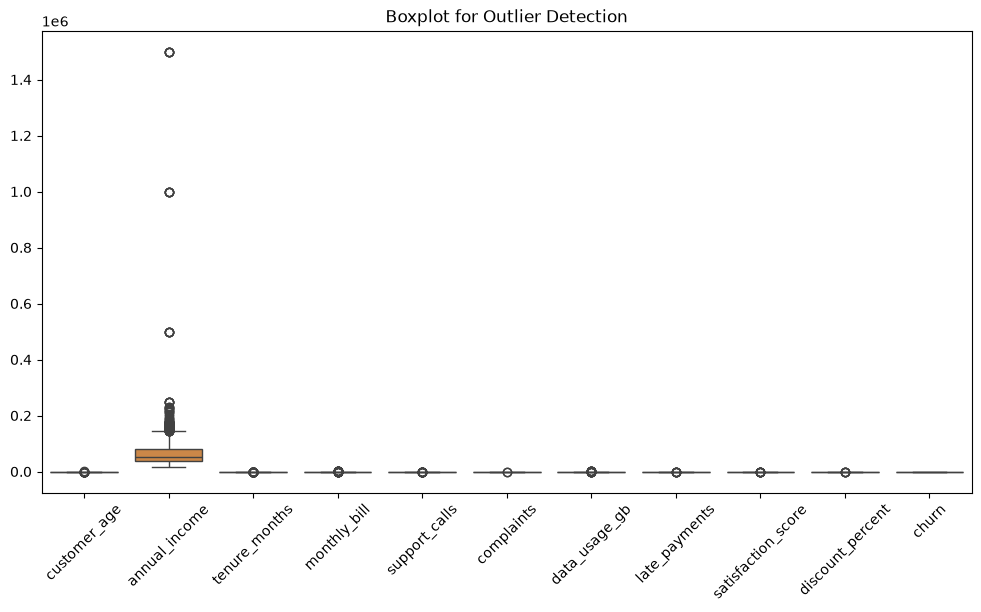

In [13]:
# check the outliar
plt.figure(figsize=(12, 6))

sns.boxplot(data=df)

plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [14]:
df.columns

Index(['customer_age', 'annual_income', 'tenure_months', 'monthly_bill',
       'support_calls', 'complaints', 'data_usage_gb', 'late_payments',
       'satisfaction_score', 'discount_percent', 'contract_type',
       'internet_service', 'payment_method', 'region', 'churn'],
      dtype='str')

In [15]:
df.dtypes

customer_age          float64
annual_income         float64
tenure_months         float64
monthly_bill          float64
support_calls         float64
complaints            float64
data_usage_gb         float64
late_payments         float64
satisfaction_score    float64
discount_percent      float64
contract_type             str
internet_service          str
payment_method            str
region                    str
churn                   int64
dtype: object

In [16]:
# check the imbalance
df['churn'].value_counts()

churn
0    1480
1     520
Name: count, dtype: int64

In [17]:
# drop the missing values and duplicated values
df.columns= df.columns.str.title().str.replace('','')

In [18]:
df.columns

Index(['Customer_Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Bill',
       'Support_Calls', 'Complaints', 'Data_Usage_Gb', 'Late_Payments',
       'Satisfaction_Score', 'Discount_Percent', 'Contract_Type',
       'Internet_Service', 'Payment_Method', 'Region', 'Churn'],
      dtype='str')

In [19]:
# handled the missing values
# check the perecentage of the value
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)


Customer_Age           4.95
Annual_Income          3.95
Tenure_Months          3.00
Monthly_Bill           2.70
Support_Calls          3.60
Complaints             3.70
Data_Usage_Gb          5.45
Late_Payments          5.30
Satisfaction_Score     4.10
Discount_Percent       3.20
Contract_Type          4.20
Internet_Service      12.60
Payment_Method         3.45
Region                 3.85
Churn                  0.00
dtype: float64


In [20]:
# handle the missing values with the median
# Numerical columns → fill with median
numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())


# Categorical columns → fill with mode
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [21]:
# check the null values are there are not
df.isnull().sum()

Customer_Age          0
Annual_Income         0
Tenure_Months         0
Monthly_Bill          0
Support_Calls         0
Complaints            0
Data_Usage_Gb         0
Late_Payments         0
Satisfaction_Score    0
Discount_Percent      0
Contract_Type         0
Internet_Service      0
Payment_Method        0
Region                0
Churn                 0
dtype: int64

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.duplicated().any()

np.False_

In [24]:
# Handle outliers using IQR method

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # clip techniques
    df[column] = np.clip(df[column], lower_bound,upper_bound)

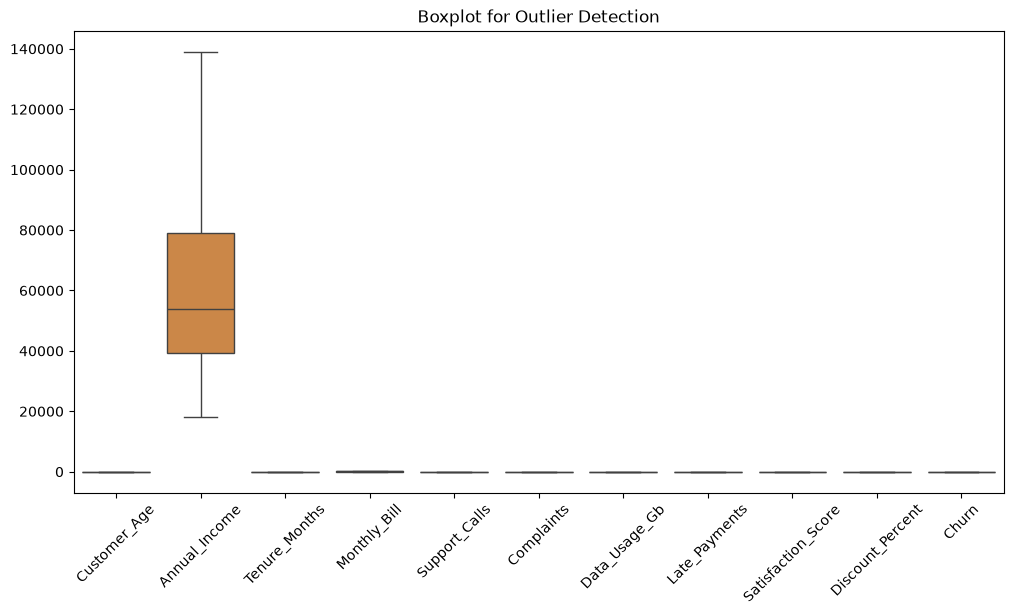

In [25]:
# check the outliar are there or not
plt.figure(figsize=(12, 6))

sns.boxplot(data=df)

plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

In [26]:
# check the unique values
# Get categorical columns
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    print(column, ":", df[column].nunique())

Contract_Type : 6
Internet_Service : 6
Payment_Method : 8
Region : 7


In [27]:
# display unique clms
categorical_columns = df.select_dtypes(include='object').columns
print(column, ":", df[column].unique())

Region : <StringArray>
['North', 'East', 'West', 'South', 'Central', 'south ', ' SOUTH']
Length: 7, dtype: str


In [28]:
# Unique value count for each column

for column in df.columns:
    print("\n" + "=" * 50)
    print("Column:", column)
    print("Number of unique values:", df[column].nunique())
    print("\nValue counts:")
    print(df[column].value_counts(dropna=False))


Column: Customer_Age
Number of unique values: 49

Value counts:
Customer_Age
37.0    164
18.0     80
41.0     76
36.0     74
34.0     72
38.0     70
43.0     69
39.0     69
42.0     69
35.0     65
40.0     61
32.0     57
33.0     54
31.0     53
45.0     51
44.0     49
47.0     49
29.0     49
46.0     47
26.0     44
25.0     42
30.0     42
27.0     40
48.0     39
49.0     39
28.0     37
50.0     36
54.0     32
23.0     29
22.0     28
24.0     26
52.0     25
21.0     25
51.0     25
53.0     24
19.0     21
9.0      20
55.0     17
20.0     17
58.0     16
65.0     16
57.0     15
56.0     12
59.0      8
60.0      8
61.0      6
63.0      6
64.0      5
62.0      2
Name: count, dtype: int64

Column: Annual_Income
Number of unique values: 1741

Value counts:
Annual_Income
139043.0    104
53710.0      78
18000.0      46
48333.0       2
49782.0       2
           ... 
45849.0       1
20620.0       1
128762.0      1
123038.0      1
27165.0       1
Name: count, Length: 1741, dtype: int64

Column: T

In [ ]:
# check the unique values
for column in df.columns:
    print("\n", column)
    print(df[column].unique())


 Customer_Age
[55. 35. 46. 37. 31. 44. 38. 36. 43. 34. 39. 32. 45. 48. 47. 58. 50. 54.
 41. 23. 61. 52. 42. 28. 27. 19. 59. 53. 18. 22. 64. 21. 25. 26. 30. 33.
 29. 20. 49. 51. 56. 57. 40. 65.  9. 24. 62. 60. 63.]

 Annual_Income
[ 62038.  79163.  72884. ... 128762. 123038.  27165.]

 Tenure_Months
[24.7    65.4625 17.4    24.5    43.7    24.2    19.3    27.7    56.8
 27.9    20.     25.1    31.9    57.4    36.6    35.6    28.8    30.3
 37.5    17.2    34.8    43.4     3.9    18.6    25.     36.4    34.6
 29.7    10.9    33.6     8.2    10.8    12.1    23.7    25.7    25.5
 45.2    23.5    41.8    18.2    59.7    54.1    20.8     8.9     1.
 59.4    27.1    16.2    37.6    17.1    22.1    15.     19.2    14.
 14.1    10.6    13.2    29.     20.7    29.2    18.1    17.7    33.1
 22.9    38.8    53.5    21.5    13.     26.1    41.5    12.7    44.
  9.3    32.3    14.3    25.4    20.5    27.5    40.9    22.3    30.1
 41.     16.1    49.7    37.1    19.7    28.2    14.4    17.8    31.2
 2

In [47]:
print(df.columns.tolist())

['Customer_Age', 'Annual_Income', 'Tenure_Months', 'Monthly_Bill', 'Support_Calls', 'Complaints', 'Data_Usage_Gb', 'Late_Payments', 'Satisfaction_Score', 'Discount_Percent', 'Contract_Type', 'Internet_Service', 'Payment_Method', 'Region', 'Churn']


In [48]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print(df.columns.tolist())

['customer_age', 'annual_income', 'tenure_months', 'monthly_bill', 'support_calls', 'complaints', 'data_usage_gb', 'late_payments', 'satisfaction_score', 'discount_percent', 'contract_type', 'internet_service', 'payment_method', 'region', 'churn']


In [49]:
# changetype string remove white space conver to lower for catgorical
categorical_columns = [
    'contract_type',
    'internet_service',
    'payment_method',
    'region'
]

for column in categorical_columns:
    df[column] = df[column].astype('string').str.strip().str.lower()

In [50]:
for column in categorical_columns:
    print(column, ":", df[column].nunique())

contract_type : 4
internet_service : 3
payment_method : 5
region : 5


In [29]:
# Step 5: Feature Engineering
# import onehotencoder
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_data = encoder.fit_transform(df[categorical_columns])
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=df.index
)

print(encoded_df)

      Contract_Type_ MONTH-TO-MONTH   Contract_Type_Month to Month  \
0                                0.0                           0.0   
1                                0.0                           0.0   
2                                0.0                           0.0   
3                                0.0                           0.0   
4                                0.0                           0.0   
...                              ...                           ...   
1995                             0.0                           0.0   
1996                             0.0                           0.0   
1997                             0.0                           0.0   
1998                             0.0                           0.0   
1999                             0.0                           0.0   

      Contract_Type_Month-to-month  Contract_Type_One year  \
0                              1.0                     0.0   
1                              0.0 

In [30]:
encoded_df

,Contract_Type_ MONTH-TO-MONTH,Contract_Type_Month to Month,Contract_Type_Month-to-month,Contract_Type_One year,Contract_Type_Two year,Contract_Type_month-to-month,Internet_Service_5G,Internet_Service_DSL,Internet_Service_FIBER,Internet_Service_Fiber,...,Payment_Method_UPI,Payment_Method_UPI,Payment_Method_upi,Region_ SOUTH,Region_Central,Region_East,Region_North,Region_South,Region_West,Region_south
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1997,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [31]:
# make both combined original and encoded datframe
# Remove original categorical columns from original dataframe
df_original = df.drop(columns=categorical_columns)

# Combine original numerical columns + encoded categorical columns
df_combined = pd.concat([df_original, encoded_df], axis=1)

# Display final dataframe
print(df_combined.head())

   Customer_Age  Annual_Income  Tenure_Months  Monthly_Bill  Support_Calls  \
0          55.0        62038.0        24.7000         88.11            1.0   
1          35.0        79163.0        65.4625        143.45            3.0   
2          46.0        72884.0        17.4000         72.68            2.0   
3          37.0        44419.0        24.5000         77.62            2.0   
4          31.0        93307.0        43.7000         71.38            3.0   

   Complaints  Data_Usage_Gb  Late_Payments  Satisfaction_Score  \
0         1.0          20.15            1.0                 6.1   
1         2.0          25.61            2.0                 6.4   
2         0.0           3.37            2.0                 8.4   
3         1.0          13.42            2.0                 6.0   
4         0.0          13.88            0.0                 8.1   

   Discount_Percent  ...  Payment_Method_UPI  Payment_Method_UPI   \
0              20.1  ...                 0.0               

In [32]:
df.duplicated().any()

np.False_

In [33]:
df.isnull().sum()

Customer_Age          0
Annual_Income         0
Tenure_Months         0
Monthly_Bill          0
Support_Calls         0
Complaints            0
Data_Usage_Gb         0
Late_Payments         0
Satisfaction_Score    0
Discount_Percent      0
Contract_Type         0
Internet_Service      0
Payment_Method        0
Region                0
Churn                 0
dtype: int64

In [34]:
df.dropna(inplace=True)

In [ ]:
print(X.dtypes)

customer_age          float64
annual_income         float64
tenure_months         float64
monthly_bill          float64
support_calls         float64
complaints            float64
data_usage_gb         float64
late_payments         float64
satisfaction_score    float64
discount_percent      float64
contract_type          string
internet_service       string
payment_method         string
region                 string
dtype: object


In [ ]:

# Handle imbalanced data using SMOTE oversampling

%pip install imbalanced-learn



Note: you may need to restart the kernel to use updated packages.


In [43]:
df_combined = pd.concat(
    [df.drop(columns=categorical_columns), encoded_df],
    axis=1
)

In [46]:
X = df_combined.drop('Churn', axis=1)
y = df_combined['Churn']

In [47]:
print(X.dtypes)

Customer_Age                      float64
Annual_Income                     float64
Tenure_Months                     float64
Monthly_Bill                      float64
Support_Calls                     float64
Complaints                        float64
Data_Usage_Gb                     float64
Late_Payments                     float64
Satisfaction_Score                float64
Discount_Percent                  float64
Contract_Type_ MONTH-TO-MONTH     float64
Contract_Type_Month to Month      float64
Contract_Type_Month-to-month      float64
Contract_Type_One year            float64
Contract_Type_Two year            float64
Contract_Type_month-to-month      float64
Internet_Service_5G               float64
Internet_Service_DSL              float64
Internet_Service_FIBER            float64
Internet_Service_Fiber            float64
Internet_Service_Fiber            float64
Internet_Service_fiber            float64
Payment_Method_ UPI               float64
Payment_Method_AutoPay            

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

In [49]:
print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
Churn
0    1465
1     515
Name: count, dtype: int64

After SMOTE:
Churn
1    1465
0    1465
Name: count, dtype: int64


In [50]:
# train and test datsets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1584, 37)
X_test: (396, 37)
y_train: (1584,)
y_test: (396,)


In [51]:
# again apply smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Churn
0    1172
1     412
Name: count, dtype: int64

After SMOTE:
Churn
1    1172
0    1172
Name: count, dtype: int64


In [52]:
# import randome forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_resampled,
    y_train_resampled
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [53]:
y_pred = rf_model.predict(X_test)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [54]:
# check the error matrics and confusion matrixs
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7575757575757576

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.85       293
           1       0.63      0.17      0.26       103

    accuracy                           0.76       396
   macro avg       0.70      0.57      0.56       396
weighted avg       0.73      0.76      0.70       396



In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)


print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[283  10]
 [ 86  17]]


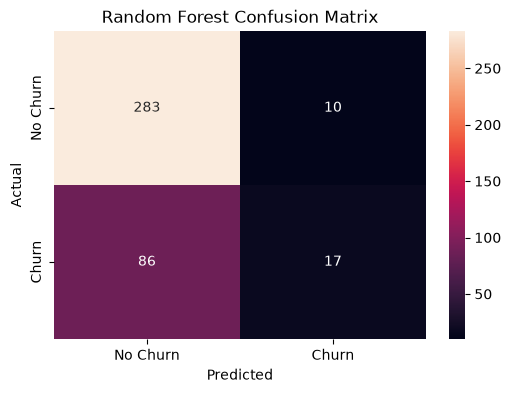

In [56]:
# give me graph
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [57]:
# with cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    rf_model,
    X_train_resampled,
    y_train_resampled,
    cv=cv,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean Cross Validation Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.84221748 0.80597015 0.82515991 0.8315565  0.81623932]

Mean Cross Validation Accuracy:
0.8242286734824049


In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Create the Random Forest model
model = RandomForestRegressor(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)

# Fit GridSearchCV
grid_search.fit( X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best score
print("Best Score:", grid_search.best_score_)

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Score: 0.04500066487934271


In [59]:
# with hyperparameter tuning using GridSearchCV

from sklearn.model_selection import GridSearchCV

#make the parameter grid for hyperparameter tuning

param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]  # Whether bootstrap samples are used when building trees
}

# create an instance of GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1)

# fit the grid search to the data
grid_search.fit(X_train, y_train)  # Fit the grid search to the training data

# print the best parameters and best score from the grid search
print(f"Best Parameters: {grid_search.best_params_}")  # Print the best parameters
print(f"Best Score: {grid_search.best_score_}")  # Print the best score

Best Parameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Score: 0.04500066487934271
